# MiniGPT from scratch — Colab runner (timeout-safe)
Runs everything end to end: tests → architecture evidence → overfit gate → training → samples → attention maps → ablations → API check.

**Timeout-safe design:** `outputs/` and `checkpoints/` live on Google Drive, and training/ablations **resume automatically** from the last saved step.
If Colab disconnects: reconnect, run cells 1–2 (setup + Drive) again, then re-run the cell that was running. It continues where it stopped.

**First:** `Runtime → Change runtime type → T4 GPU`.

In [1]:
REPO_URL = "https://github.com/adeena43/Small-Language-Model.git"
QUICK = False            # True = short smoke run (a few minutes)
MAIN_STEPS = 5000        # steps for the main model
ABLATION_STEPS = 2000    # steps per ablation run
ABLATION_SMALL = True    # True = ablations use a smaller model (d_model 128) so they finish faster; document this in the report

In [2]:
# ---- CELL 1: setup (re-run after every disconnect) ----
import os, torch
if not os.path.exists("Small-Language-Model"):
    !git clone $REPO_URL Small-Language-Model
%cd Small-Language-Model
!git pull -q
!pip install -q -r requirements-train.txt
from IPython.display import Image, display
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Cloning into 'Small-Language-Model'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 153 (delta 34), reused 144 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 13.06 MiB | 33.35 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Small-Language-Model
torch 2.11.0+cu130 | cuda: True | Tesla T4


In [3]:
# ---- CELL 2: Google Drive (re-run after every disconnect) ----
# outputs/ and checkpoints/ are stored on Drive, so nothing is lost when the runtime dies.
from google.colab import drive
drive.mount('/content/drive')
P = "/content/drive/MyDrive/minigpt_runs"
os.makedirs(P + "/outputs", exist_ok=True); os.makedirs(P + "/checkpoints", exist_ok=True)
!cp -rn outputs/. {P}/outputs/ 2>/dev/null
!cp -rn checkpoints/. {P}/checkpoints/ 2>/dev/null
!rm -rf outputs checkpoints
!ln -s {P}/outputs outputs
!ln -s {P}/checkpoints checkpoints
!ls -la | grep -E "outputs|checkpoints"
!ls checkpoints

Mounted at /content/drive
lrwxrwxrwx  1 root root    47 Oct  4 09:22 checkpoints -> /content/drive/MyDrive/minigpt_runs/checkpoints
lrwxrwxrwx  1 root root    43 Oct  4 09:22 outputs -> /content/drive/MyDrive/minigpt_runs/outputs
best.pt


## 1. Unit tests

In [4]:
!python -m pytest -q

...............................                                          [100%]
31 passed in 16.52s


## 2. Architecture evidence (Figures 1–5)

INPUTS (3 tokens, d_k = d_v = 2)

Q =
[[1. 0.]
 [0. 1.]
 [1. 1.]]

K =
[[1. 0.]
 [0. 1.]
 [1. 1.]]

V =
[[1. 2.]
 [3. 4.]
 [5. 6.]]

Step 1: scores = Q K^T
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

Step 2: divide by sqrt(d_k) = sqrt(2) = 1.4142
[[0.7071 0.     0.7071]
 [0.     0.7071 0.7071]
 [0.7071 0.7071 1.4142]]

Step 3: row-wise softmax -> attention weights (each row sums to 1)
[[0.4011 0.1978 0.4011]
 [0.1978 0.4011 0.4011]
 [0.2483 0.2483 0.5035]]

   row sums =
[1. 1. 1.]

Step 4: output = weights @ V
[[3.     4.    ]
 [3.4067 4.4067]
 [3.5105 4.5105]]

Step 5: CAUSAL MASK -> masked score matrix (future positions = -inf)
[[0.7071   -inf   -inf]
 [0.     0.7071   -inf]
 [0.7071 0.7071 1.4142]]

Step 6: softmax of masked scores (exp(-inf) = 0 so future weights are exactly 0)
[[1.     0.     0.    ]
 [0.3302 0.6698 0.    ]
 [0.2483 0.2483 0.5035]]

Step 7: masked output = masked_weights @ V
[[1.     2.    ]
 [2.3395 3.3395]
 [3.5105 4.5105]]

WHAT CHANGED (information available to eac

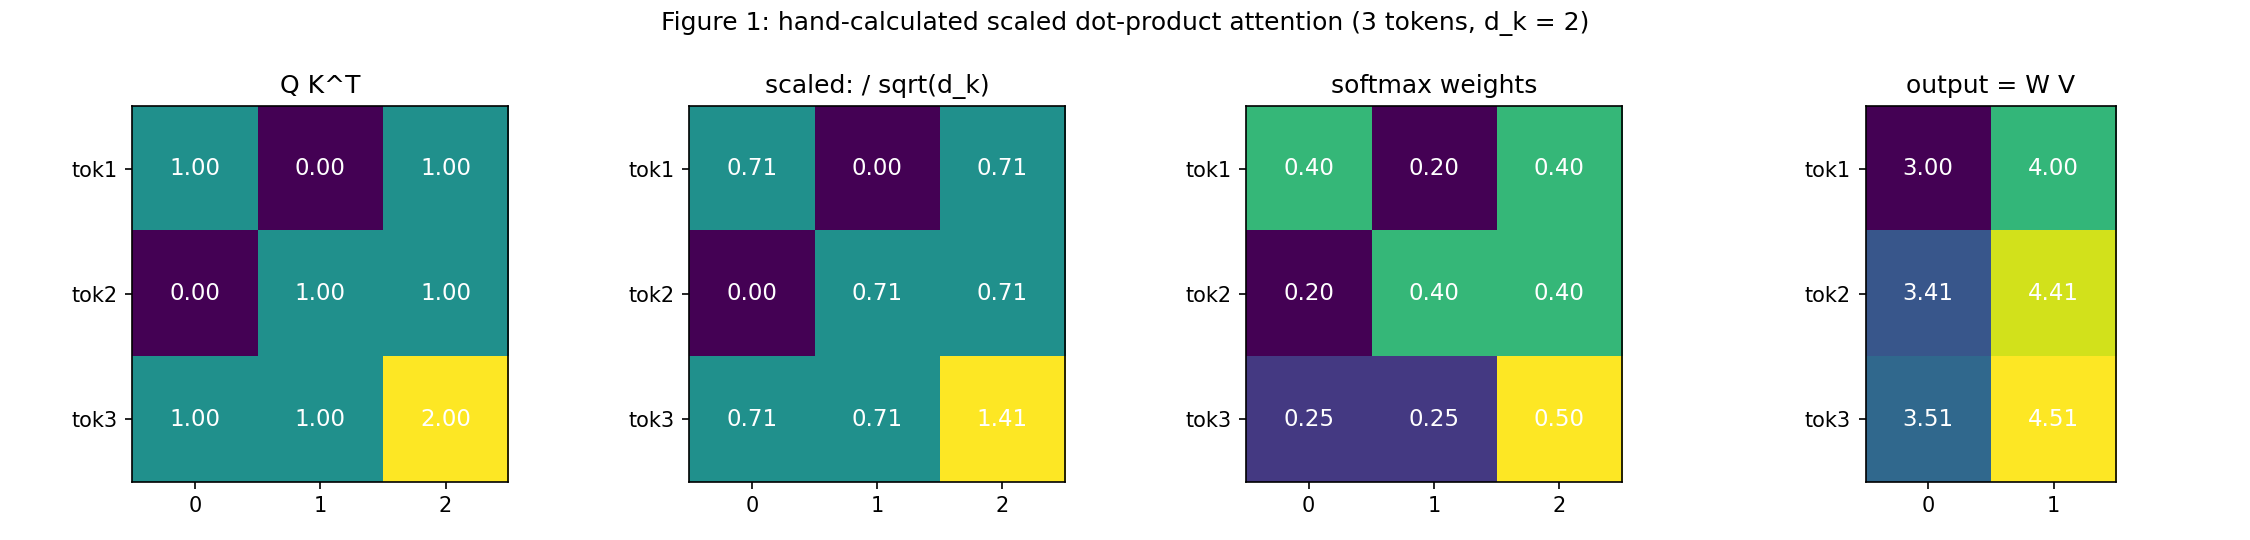

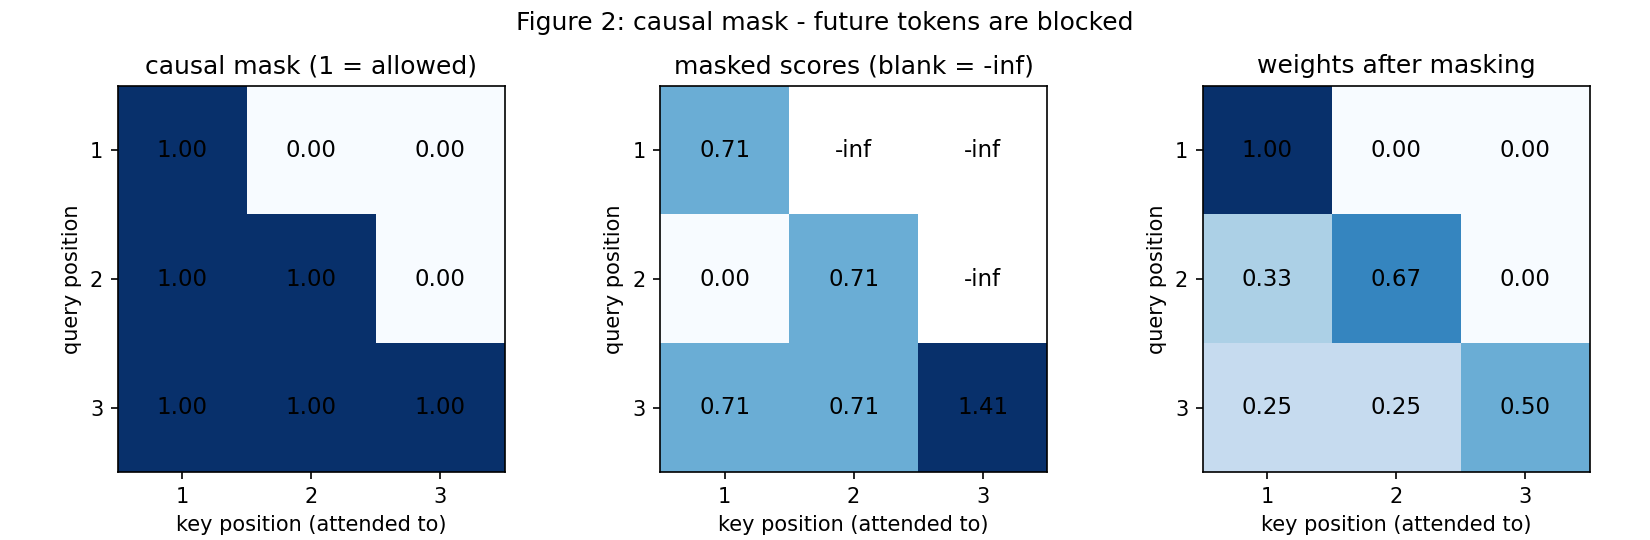

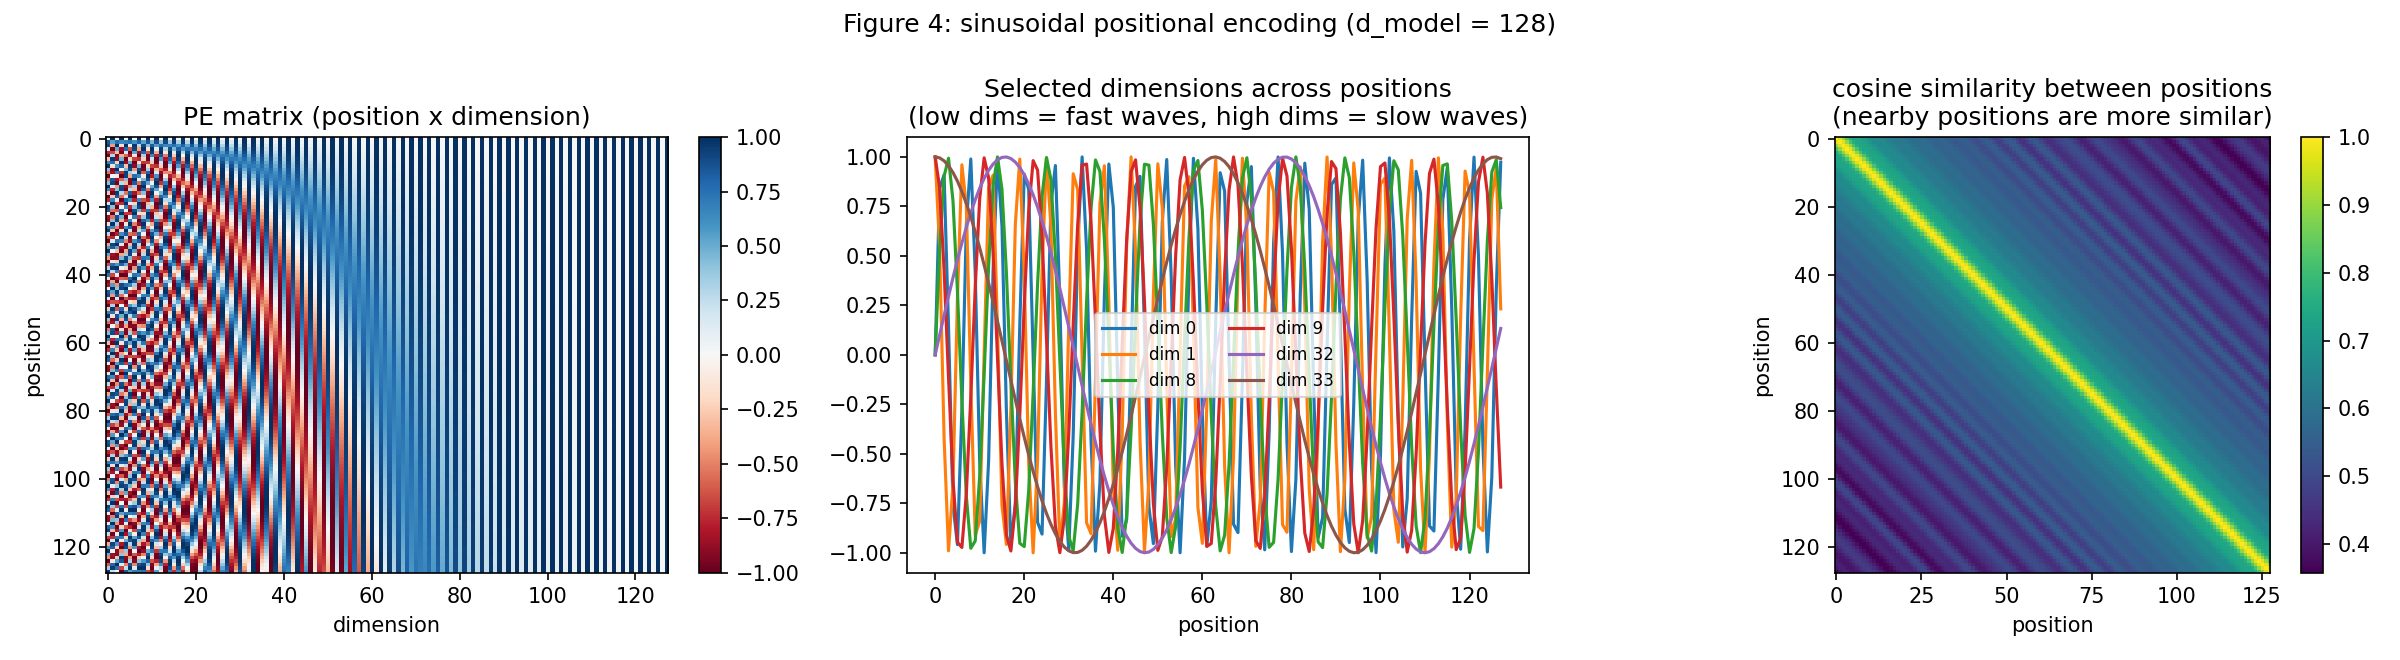

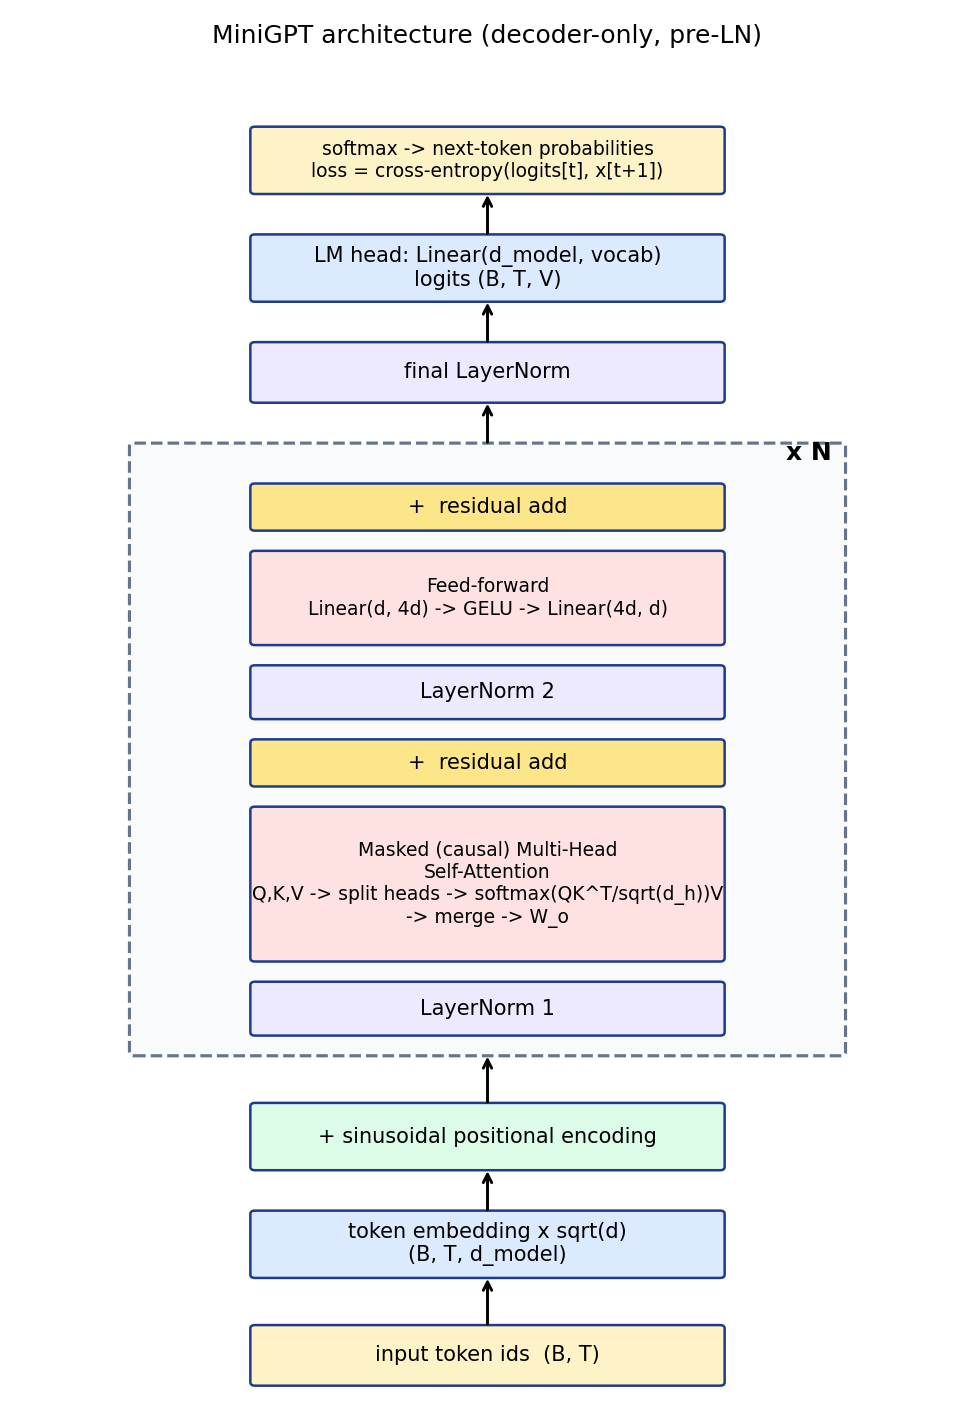

In [5]:
!python experiments/hand_calculation.py
!python experiments/shape_trace.py
!python experiments/positional_encoding_viz.py
!python experiments/architecture_diagram.py
for f in ["fig1_hand_attention", "fig2_causal_mask", "fig4_positional_encoding", "architecture_diagram"]:
    display(Image(f"outputs/figures/{f}.png"))

## 3. Why Transformers (sequential vs parallel) and MLM-vs-CLM comparison

device: Tesla T4
T=  32 | RNN loop     2.26 ms (32 sequential steps) | attention     0.43 ms (1 step) | T x T maps 0.12 MB
T=  64 | RNN loop     5.46 ms (64 sequential steps) | attention     0.43 ms (1 step) | T x T maps 0.50 MB
T= 128 | RNN loop     9.68 ms (128 sequential steps) | attention     0.43 ms (1 step) | T x T maps 2.00 MB
T= 256 | RNN loop    18.52 ms (256 sequential steps) | attention     0.84 ms (1 step) | T x T maps 8.00 MB
T= 512 | RNN loop    38.23 ms (512 sequential steps) | attention     2.41 ms (1 step) | T x T maps 32.00 MB

| property (per layer)             | RNN            | Self-attention |
|----------------------------------|----------------|----------------|
| sequential operations            | O(T)           | O(1)           |
| compute per layer                | O(T * d^2)     | O(T^2 * d)     |
| memory for pairwise scores       | none           | O(T^2) per head|
| max path length between 2 tokens | O(T)           | O(1)           |

saved /content/Small-

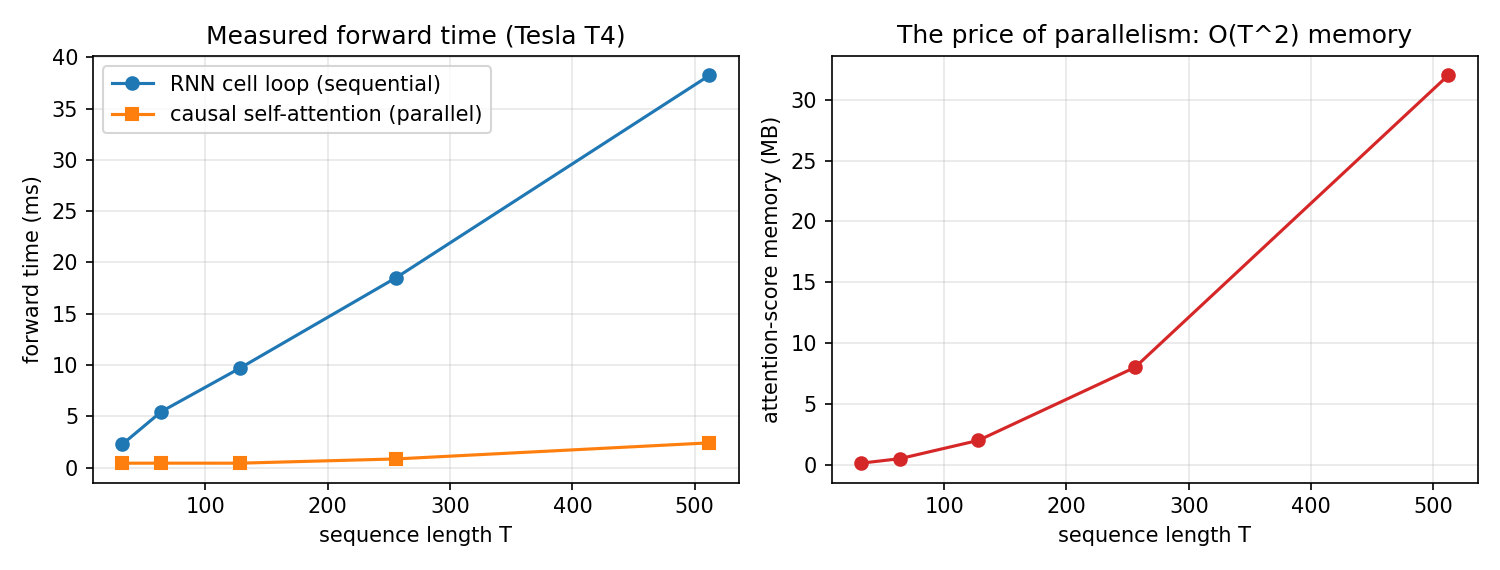

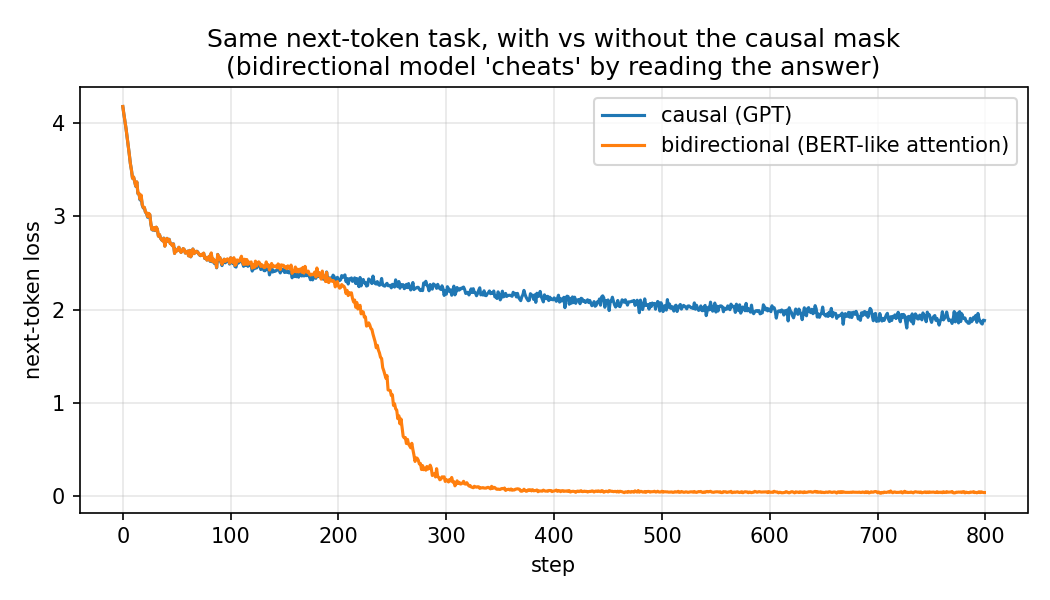

In [6]:
!python experiments/why_transformers.py
!python experiments/mask_comparison.py
display(Image("outputs/figures/why_transformers.png")); display(Image("outputs/figures/fig6c_mlm_vs_clm_training.png"))

## 4. Debugging gate: overfit a tiny batch (loss must collapse)

In [7]:
!python -m src.train --overfit_tiny

overfit step    0 | loss 4.2531
overfit step   25 | loss 0.5404
overfit step   50 | loss 0.0081
overfit step   75 | loss 0.0010
overfit step  100 | loss 0.0005
overfit step  125 | loss 0.0004
overfit step  150 | loss 0.0003
overfit step  175 | loss 0.0003
overfit step  200 | loss 0.0002
overfit step  225 | loss 0.0002
overfit step  250 | loss 0.0002
overfit step  275 | loss 0.0002
overfit step  299 | loss 0.0002

initial loss 4.2531 -> final loss 0.0002


## 5. Train the main MiniGPT (resumable: if it disconnects, just re-run this cell)

In [8]:
steps = 300 if QUICK else MAIN_STEPS
eval_i = 250 if steps >= 1000 else 50
samp_i = 1000 if steps >= 1000 else 100
!python -m src.train --resume --set train.max_steps={steps} train.eval_interval={eval_i} train.sample_interval={samp_i}

device=cuda | dataset={'num_characters': 1115394, 'num_lines': 40001, 'vocab_size': 65, 'train_tokens': 1003854, 'val_tokens': 111540}
MiniGPT model summary
vocab_size        : 65
context_length    : 128
d_model           : 256
n_heads           : 4  (head_dim = 64)
n_layers          : 4
ffn_dim           : 1024
dropout           : 0.1
position encoding : sinusoidal
weight tying      : False
------------------------------------------------------
token embedding   :     16,640
position encoding :          0  (fixed buffer, no parameters)
each block (x4)   :    789,760
  - attention     :    263,168
  - feed-forward  :    525,568
  - 2 LayerNorms  :      1,024
final LayerNorm   :        512
LM head           :     16,640
------------------------------------------------------
TOTAL parameters  :  3,192,832  (3.19M)
step     0 | train 4.2899 | val 4.2893 (ppl 72.92) | lr 3.00e-06 | 0 tok/s
step   250 | train 2.3316 | val 2.3465 (ppl 10.45) | lr 2.99e-04 | 124,499 tok/s
step   500 | train 2

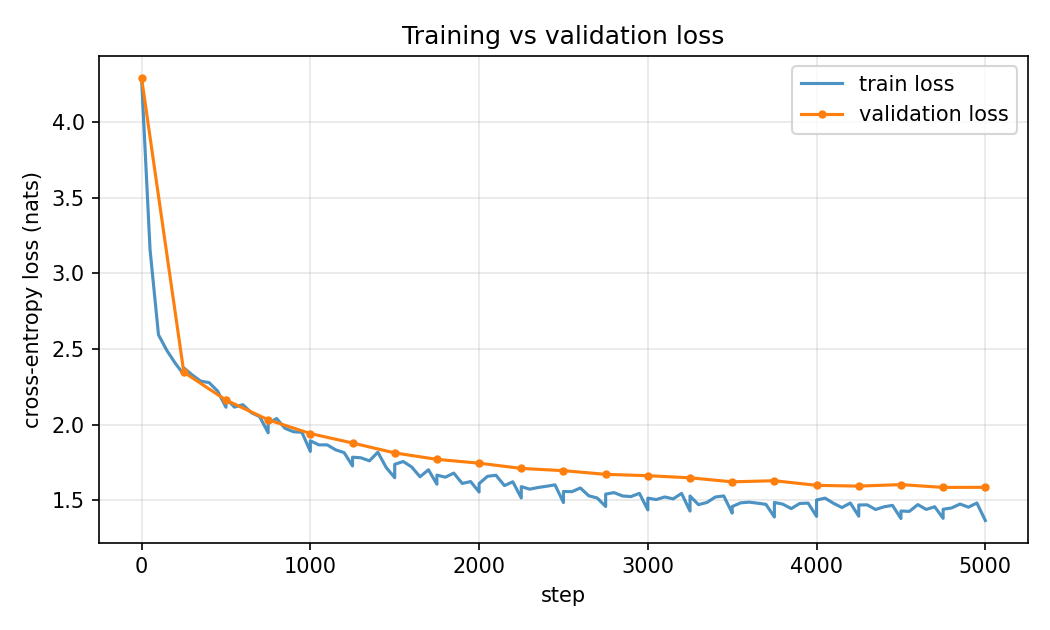

{
  "run_name": "main",
  "parameters": 3192832,
  "model_config": {
    "vocab_size": 65,
    "context_length": 128,
    "d_model": 256,
    "n_heads": 4,
    "n_layers": 4,
    "ffn_dim": 1024,
    "dropout": 0.1,
    "pos_encoding": "sinusoidal",
    "weight_tying": false
  },
  "train_config": {
    "optimizer": "adamw",
    "lr": 0.0003,
    "min_lr": 3e-05,
    "warmup_steps": 100,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "batch_size": 64,
    "max_steps": 5000,
    "eval_interval": 250,
    "eval_batches": 20,
    "save_interval": 250,
    "log_interval": 50,
    "sample_interval": 1000,
    "sample_prompt": "ROMEO:",
    "sample_tokens": 200,
    "device": "auto",
    "out_dir": "outputs",
    "checkpoint_dir": "checkpoints"
  },
  "dataset": {
    "num_characters": 1115394,
    "num_lines": 40001,
    "vocab_size": 65,
    "train_tokens": 1003854,
    "val_tokens": 111540
  },
  "device": "cuda",
  "hardware": "Tesla T4",
  "wall_clock_sec": 449.1,
  "final_train_lo

In [9]:
import json
display(Image("outputs/figures/main_loss_curve.png"))
print(json.dumps(json.load(open("outputs/logs/main_summary.json")), indent=2)[:1800])

## 6. Generation (fixed prompts), evaluation, attention maps

Prompt: 'ROMEO:'
Generated: ROMEO:
You have now off, which you have senatory
Of that Oxford called him and him us her to be
Methink, endream, you fall to my more own procful
I can this now in a griefe-sent in the sea,
Who thou dest no
model parameters: 3.19M
context length: 128
temperature: 0.8
------------------------------------------------------------
Prompt: 'To be, or not to be'
Generated: To be, or not to be man!

Provost:
I am am a presued on him.

SICINIUS:
Why you love's not
To this deserved sword to again Warwick,
I prince to thee, and high him he poor of his but
To blood the fire; sir. Who fit thy f
model parameters: 3.19M
context length: 128
temperature: 0.8
------------------------------------------------------------
Prompt: 'KING HENRY:\nWhat say you'
Generated: KING HENRY:
What say you are the paint of York and friend!

QUEEN ELIZABETH:
That he may in the cause no much soldier for his need.

QUEEN ELIZABETH:
Madam, so a changed-speak between throaty who
must he wilt welc

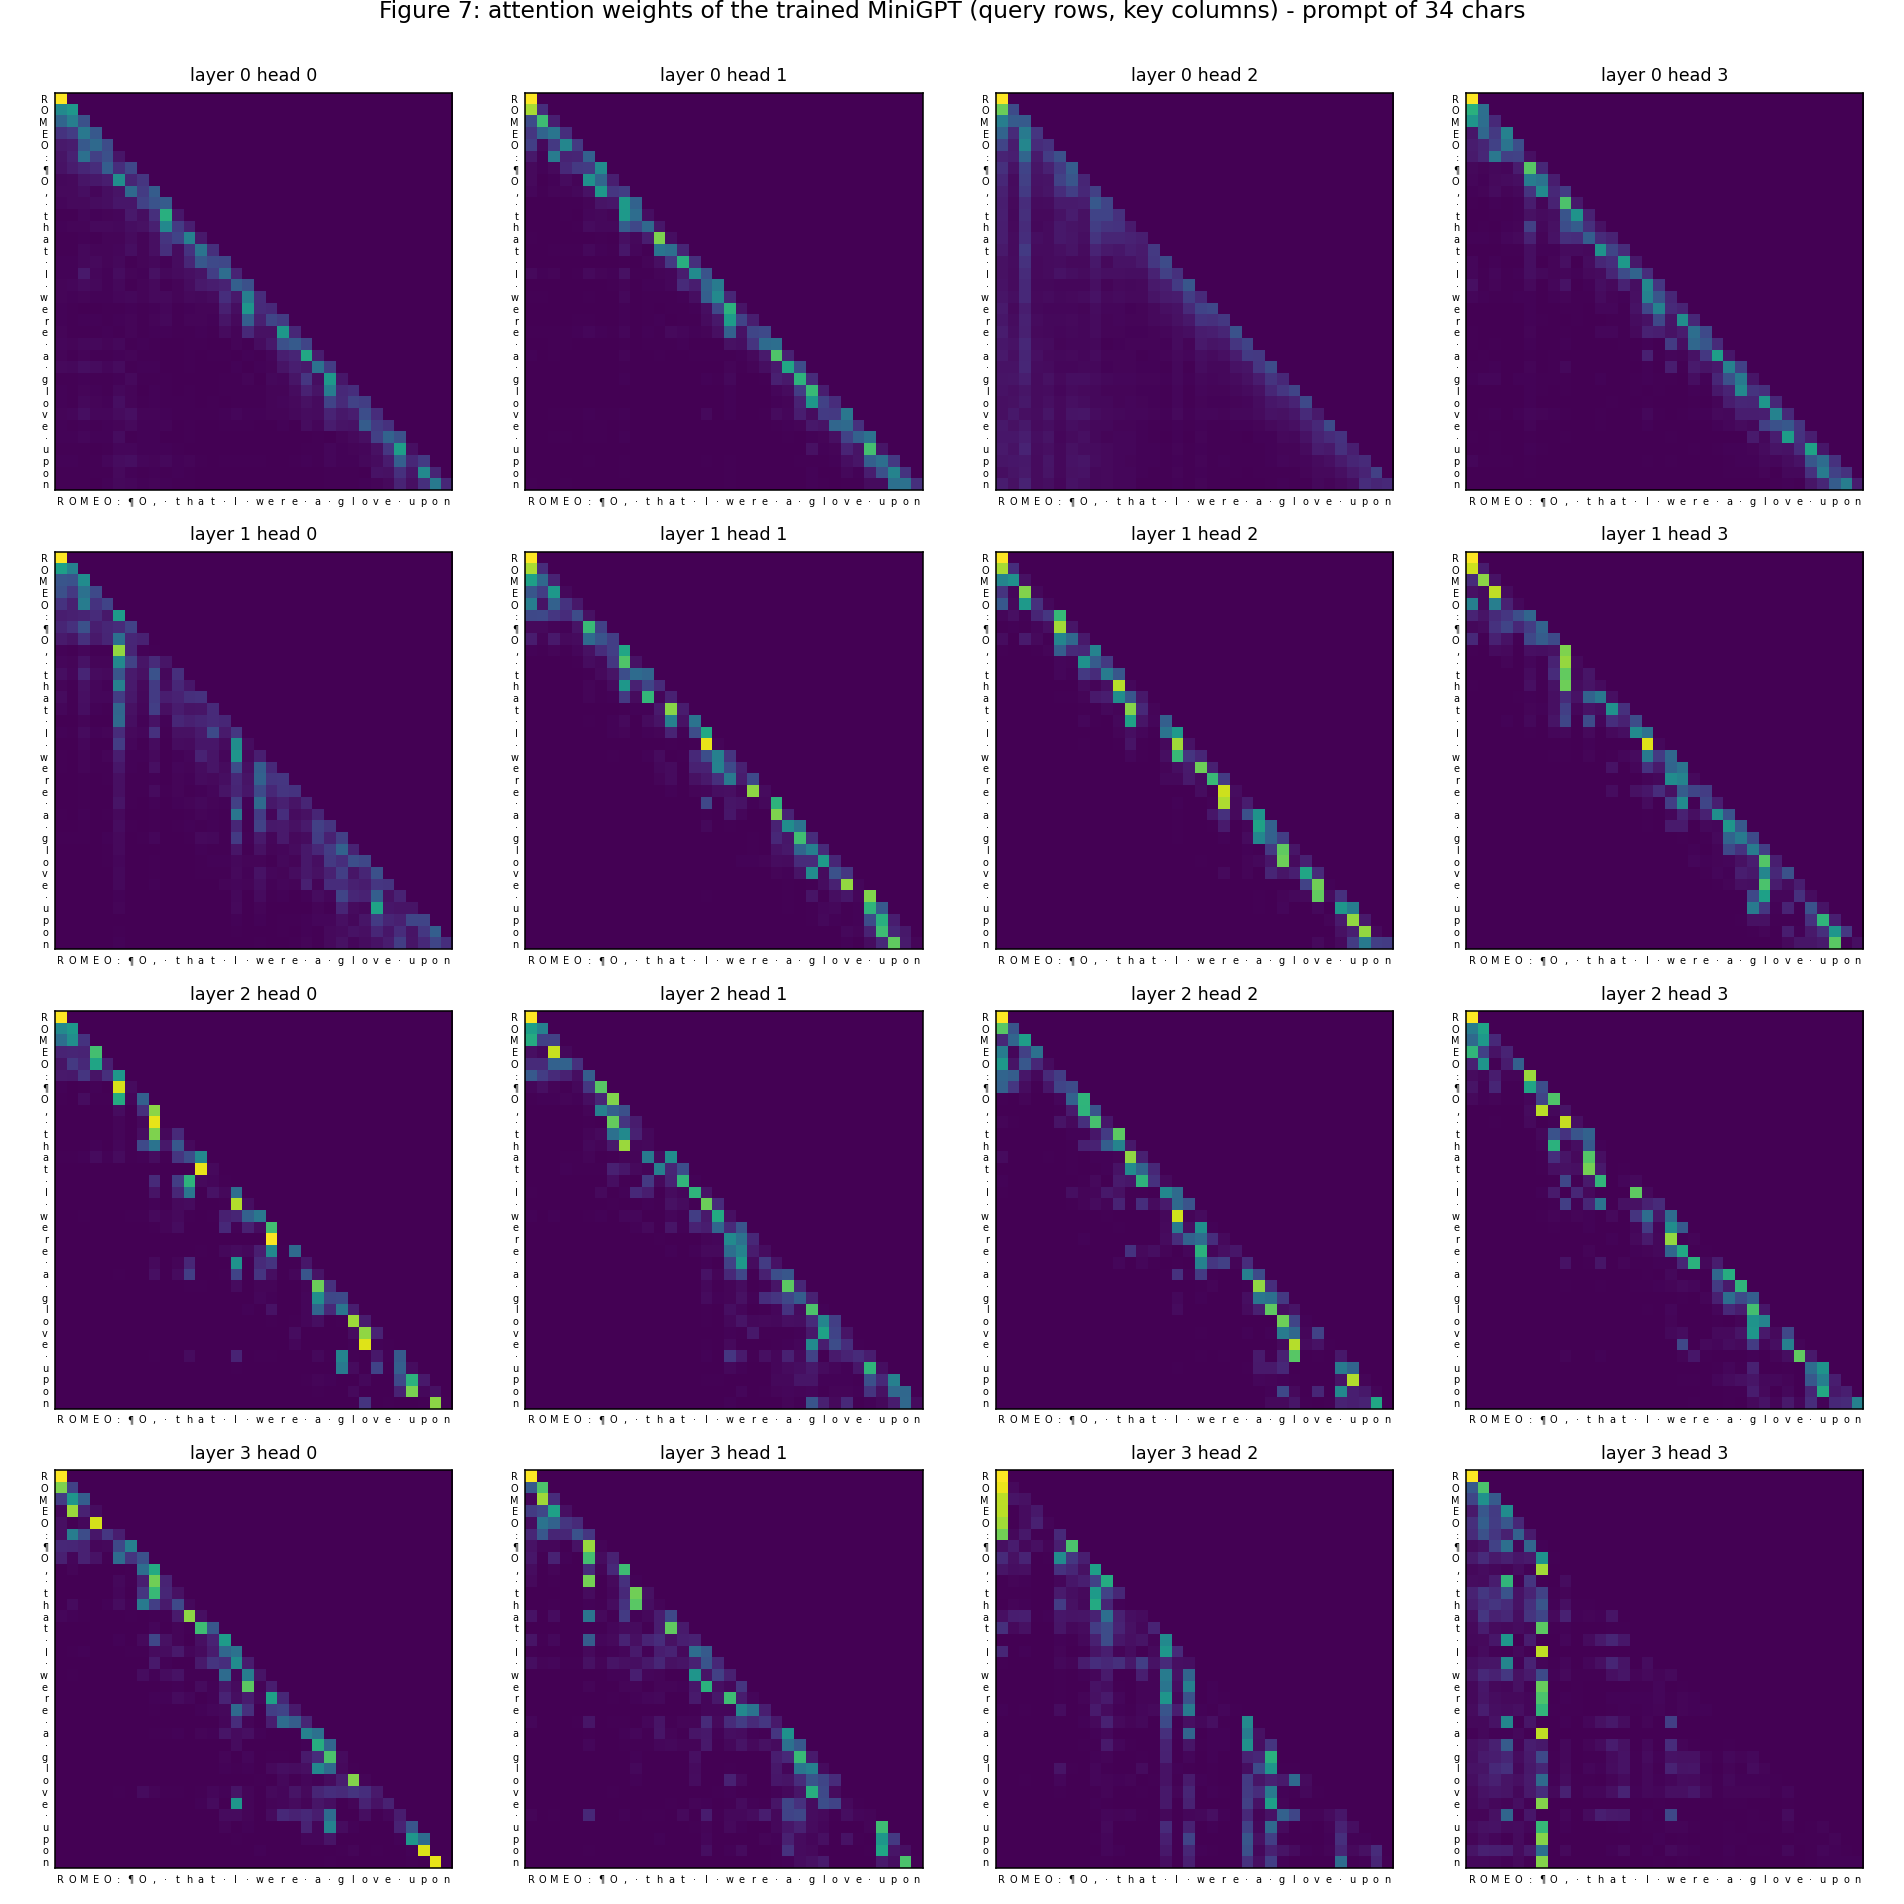

In [10]:
!python -m src.generate --fixed-prompts --max-new-tokens 200
!python experiments/evaluate.py --checkpoint checkpoints/best.pt --device cuda
!python experiments/attention_visualization.py --checkpoint checkpoints/best.pt --device cuda
display(Image("outputs/figures/fig7_attention_visualization.png"))

## 7. Ablation study — one group per cell (each run resumes automatically; finished runs are skipped)
If Colab times out in the middle of a cell: run CELL 1 and CELL 2 again, then re-run the same ablation cell.

In [11]:
s = 200 if QUICK else ABLATION_STEPS
extra = "--set model.d_model=128 model.ffn_dim=512" if ABLATION_SMALL else ""
!python experiments/ablation.py --group depth --steps {s} {extra}

[skip] depth_2 (cached, same steps/size)
[skip] depth_4 (cached, same steps/size)
[skip] depth_6 (cached, same steps/size)
/content/Small-Language-Model/experiments/ablation.py:146: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  res = pd.concat([old[~old["run"].isin(res["run"])], res], ignore_index=True)

| group   | factor         |   value | run         |   params |   final_train_loss |   final_val_loss |   val_perplexity |   train_time_sec |   tokens_per_sec |   peak_cuda_mem_MB |   valid_word_rate |   repeat_3gram_rate |
|:--------|:---------------|--------:|:------------|---------:|-------------------:|-----------------:|-----------------:|-----------------:|-----------------:|-------------------:|------------------:|-------------------

In [12]:
!python experiments/ablation.py --group heads --steps {s} {extra}

[skip] heads_2 (cached, same steps/size)
[skip] heads_4 (cached, same steps/size)
[skip] heads_8 (cached, same steps/size)
/content/Small-Language-Model/experiments/ablation.py:146: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  res = pd.concat([old[~old["run"].isin(res["run"])], res], ignore_index=True)

| group   | factor         |   value | run         |   params |   final_train_loss |   final_val_loss |   val_perplexity |   train_time_sec |   tokens_per_sec |   peak_cuda_mem_MB |   valid_word_rate |   repeat_3gram_rate |
|:--------|:---------------|--------:|:------------|---------:|-------------------:|-----------------:|-----------------:|-----------------:|-----------------:|-------------------:|------------------:|-------------------

In [13]:
!python experiments/ablation.py --group context --steps {s} {extra}

[skip] context_64 (cached, same steps/size)
[skip] context_128 (cached, same steps/size)
[skip] context_256 (cached, same steps/size)

| group   | factor         |   value | run         |   params |   final_train_loss |   final_val_loss |   val_perplexity |   train_time_sec |   tokens_per_sec |   peak_cuda_mem_MB |   valid_word_rate |   repeat_3gram_rate |
|:--------|:---------------|--------:|:------------|---------:|-------------------:|-----------------:|-----------------:|-----------------:|-----------------:|-------------------:|------------------:|--------------------:|
| depth   | n_layers       |       2 | depth_2     |   413440 |             2.1491 |           2.1851 |           8.8919 |          43.4000 |      429858.2730 |           260.8000 |               nan |                 nan |
| depth   | n_layers       |       4 | depth_4     |   809984 |             2.0803 |           2.1244 |           8.3676 |          81.2000 |      223532.7939 |           469.6000 |            

         strategy  valid_word_rate  repeat_3gram_rate
           greedy         0.974194           0.771242
         temp 0.5         0.960000           0.000000
         temp 0.8         0.909091           0.000000
         temp 1.2         0.740741           0.000000
 top-k 10 (t=0.8)         0.937500           0.000000
top-p 0.9 (t=0.8)         0.951220           0.000000


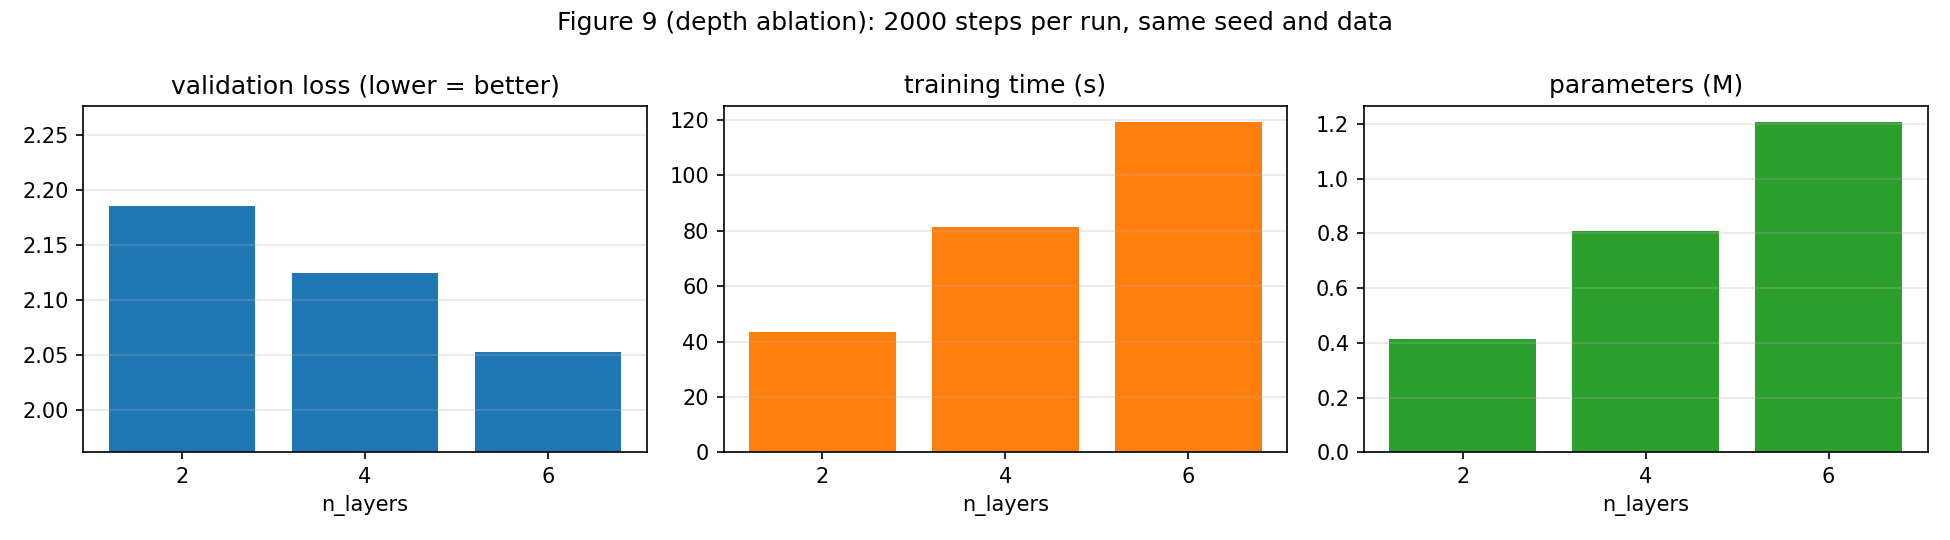

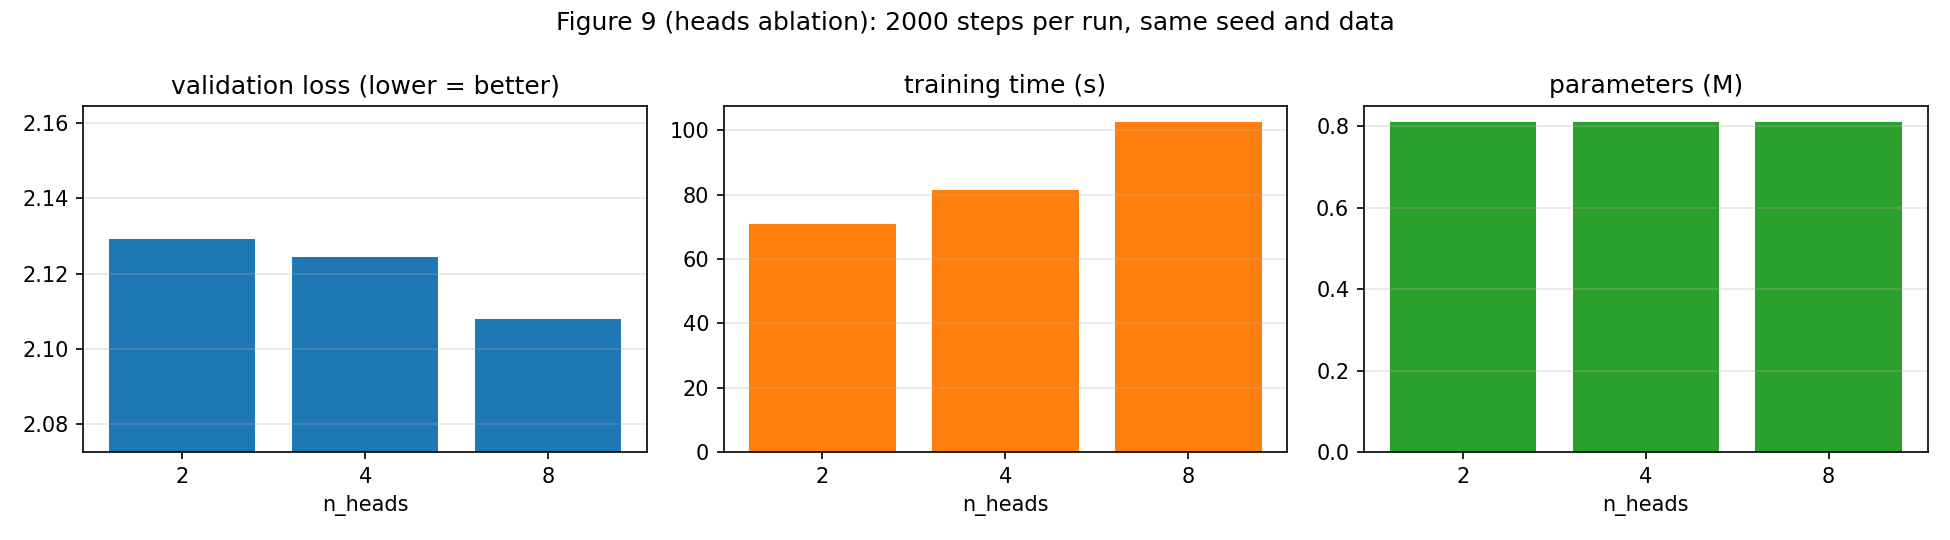

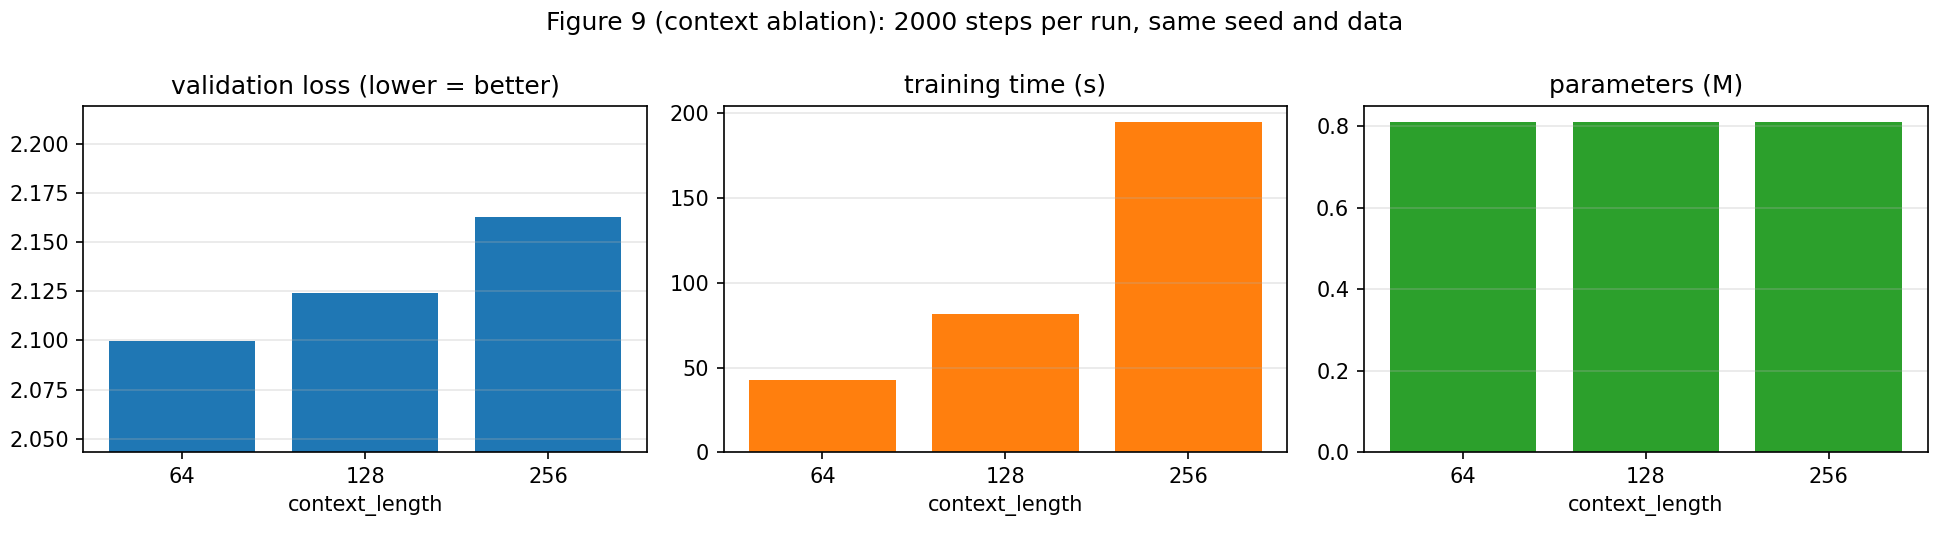

| group   | factor         |   value | run         |   params |   final_train_loss |   final_val_loss |   val_perplexity |   train_time_sec |   tokens_per_sec |   peak_cuda_mem_MB |   valid_word_rate |   repeat_3gram_rate |
|:--------|:---------------|--------:|:------------|---------:|-------------------:|-----------------:|-----------------:|-----------------:|-----------------:|-------------------:|------------------:|--------------------:|
| depth   | n_layers       |       2 | depth_2     |   413440 |             2.1491 |           2.1851 |           8.8919 |          43.4000 |      429858.2730 |           260.8000 |               nan |                 nan |
| depth   | n_layers       |       4 | depth_4     |   809984 |             2.0803 |           2.1244 |           8.3676 |          81.2000 |      223532.7939 |           469.6000 |               nan |                 nan |
| depth   | n_layers       |       6 | depth_6     |  1206528 |             1.9863 |           2.0525 | 

In [14]:
# optional extras (run only if time permits)
# !python experiments/ablation.py --group position --steps {s} {extra}
!python experiments/ablation.py --group generation --checkpoint checkpoints/best.pt
for g in ["depth", "heads", "context"]:
    display(Image(f"outputs/figures/fig9_ablation_{g}.png"))
print(open("outputs/ablation/ablation_results.md").read())

## 8. API smoke test (same app that is deployed on Render)

In [15]:
import subprocess, time, requests
server = subprocess.Popen(["uvicorn", "src.api:app", "--port", "8000"])
time.sleep(8)
print(requests.get("http://127.0.0.1:8000/health").json())
r = requests.post("http://127.0.0.1:8000/generate", json={"prompt": "ROMEO:", "max_new_tokens": 120, "temperature": 0.8})
print(r.json()["generated"])
server.terminate()

{'status': 'ok', 'detail': None}
ROMEO:
What wilt I should be noble mittate and prove
And to the contry heart.

ROMEO:
What, then have let the please.

CORIOLA


## 9. Download results (they are also already in Drive → MyDrive/minigpt_runs)

In [16]:
!zip -qr results.zip outputs/. checkpoints/best.pt
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>